In [1]:
!pip install -q -U 'skorch[pytorch]' && pip install -q -U faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 40.5 MB/s eta 0:00:00


In [2]:
## -- CHECK FOR 3RD PARTY LIBRARIES --
try:
    import pytabkit
    import skrub
except:
    %pip install pytabkit
    %pip install skrub

    import pytabkit
    import skrub

## -- PREREQUISITES FOR PyTabKit GBMs (xgb_TD, lgbm_TD, cat_TD) --
try:
    import xgboost, lightgbm, catboost
except:
    %pip install xgboost lightgbm catboost
    import xgboost, lightgbm, catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 8.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 10.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device GPU: Tesla T4
ℹ️ No. of CPU: 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibrationDisplay

import warnings

2026-03-23 21:30:56.525782: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774301456.749220      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774301456.817274      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774301457.324943      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774301457.324986      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774301457.324990      24 computation_placer.cc:177] computation placer alr

In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
# plt.style.use("ggplot")
sns.set_style("whitegrid")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- Load Data --
PATH = '/kaggle/input/competitions/playground-series-s6e3/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/telco-customer-churn/'
orig = pd.read_csv(ORIG_PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)

TARGET = train.columns[-1]
NUMS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATS   = [c for c in train.columns if c not in NUMS+[TARGET, 'id']] 
BASE   = NUMS + CATS

for df in [train, orig]:
    df[TARGET] = df[TARGET].map({'Yes': 1, 'No': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (594194, 20)
Test shape: (254655, 19)
Original shape: (7043, 20)

Total Numerical: 3
Total Categorical: 16
Total base features: 19


In [7]:
# ## -- Load data Colab --
# from google.colab import drive
# drive.mount('/content/drive')

# PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e2 | Heart Disease/_heart_dataset/'

# submit = pd.read_csv(PATH+'sample_submission.csv')
# train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
# test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

# # ORIG_PATH = '/kaggle/input/heartdisease/'
# orig = pd.read_csv(PATH+'Heart_Disease_Prediction.csv')

# ## -- Remove trailing spaces in column names --
# for col in test.columns:
#     n = col.replace(' ', '_')
#     print(f"Removing spaces in {col} to {n}")
#     train.rename(columns={col: n}, inplace=True)
#     test.rename(columns={col: n}, inplace=True)
#     orig.rename(columns={col: n}, inplace=True)

# TARGET = train.columns[-1]
# NUMS   = ['Age', 'BP', 'Cholesterol', 'Max_HR', 'ST_depression']
# CATS   = [c for c in train.columns if c not in [TARGET]+NUMS]

# BASE = NUMS + CATS

# for df in [train, orig]:
#     df[TARGET] = df[TARGET].map({'Presence': 1, 'Absence': 0})

# for (name, df) in dict(Train=train, Test=test, Original=orig).items():
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Numerical: {len(NUMS)}")
# print(f"Total Categorical: {len(CATS)}")
# print(f"Total base features: {len(BASE)}")

In [8]:
## -- FIX ORIGINAL COLUMN --
orig['TotalCharges'] = orig['TotalCharges'].replace(' ', np.nan).astype(float)
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())

display(orig.head())
orig.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [9]:
train.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,0


In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Train,72,1921,31910,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Original,73,1585,6531,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Test,72,1875,24995,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4


## FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []

In [12]:
print(f"\nEXTRACTING ROUNDS... ", end='')
for col in ['TotalCharges']:
    for r in [-3, -2, -1, 0, 1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-3, -2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    print(f"\nCREATING E_BINS... ", end='')
    for b in [400, 1000, 4000]: # 100, 500, 1000
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [1000, 4000]: # 100, 500, 1000
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)
        
print()
print('-'*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS)}')
print(f"✅ TOTAL DIGITS EXTRACTED: {len(DIGITS)}")
print(f"✅ TOTAL EQUAL E_BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE E_BINS: {len(Q_BINS)}")


EXTRACTING ROUNDS... TotalCharges_round_-3, TotalCharges_round_-2, TotalCharges_round_-1, TotalCharges_round_0, TotalCharges_round_1, 
EXTRACTING DIGITS... TotalCharges_digit_-3, TotalCharges_digit_-2, TotalCharges_digit_-1, TotalCharges_digit_0, TotalCharges_digit_1, TotalCharges_digit_2, 
CREATING E_BINS... TotalCharges_bin_400, TotalCharges_bin_1000, TotalCharges_bin_4000, 
QUANTILE BINNING... TotalCharges_Qbin_1000, TotalCharges_Qbin_4000, 
--------------------------------------------------
✅ TOTAL ROUND FEATURES: 5
✅ TOTAL DIGITS EXTRACTED: 6
✅ TOTAL EQUAL E_BINS: 3
✅ TOTAL QUANTILE E_BINS: 2


In [13]:
for col in ['MonthlyCharges']:
    print(f"\nROUNDING FEATURES... ", end='')
    for r in [-2, -1, 0]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)
    
    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)
            
    print(f"\nEQUAL BINNING... ", end='')
    for b in [100]: # 50, 100, 400
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)
        
    print(f"\nQUANTILE BINNING... ", end='')
    for q in [500]: # 50, 100, 400
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('-'*50)
print(f"✅ TOTAL DIGITS: {len(DIGITS)}")
print(f'✅ TOTAL ROUNDs: {len(ROUNDS)}')
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS)}")


ROUNDING FEATURES... MonthlyCharges_round_-2, MonthlyCharges_round_-1, MonthlyCharges_round_0, 
EXTRACTING DIGITS... MonthlyCharges_digit_-2, MonthlyCharges_digit_-1, MonthlyCharges_digit_0, MonthlyCharges_digit_1, MonthlyCharges_digit_2, 
EQUAL BINNING... MonthlyCharges_bin_100, 
QUANTILE BINNING... MonthlyCharges_Qbin_500, 
--------------------------------------------------
✅ TOTAL DIGITS: 11
✅ TOTAL ROUNDs: 7
✅ TOTAL EQUAL BINS: 4
✅ TOTAL QUANTILE BINS: 3


In [14]:
for col in ['tenure']:
    print(f"\nEXTRACTING ROUNDS... ", end='')
    for r in [-1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)
    # print()
    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-1, 0]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    print(f"\nEQUAL BINNING... ", end='')
    for b in [12]: # 10, 50
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [12]: # 10, 50
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('-'*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS):<10}')
print(f"✅ TOTAL DIGITS FEATURES: {len(DIGITS):<10}")
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS):<10}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS):<10}")


EXTRACTING ROUNDS... tenure_round_-1, 
EXTRACTING DIGITS... tenure_digit_-1, tenure_digit_0, 
EQUAL BINNING... tenure_bin_12, 
QUANTILE BINNING... tenure_Qbin_12, 
--------------------------------------------------
✅ TOTAL ROUND FEATURES: 8         
✅ TOTAL DIGITS FEATURES: 13        
✅ TOTAL EQUAL BINS: 5         
✅ TOTAL QUANTILE BINS: 4         


In [15]:
ALL_ROUND_BINS = ROUNDS + E_BINS + Q_BINS

train[ALL_ROUND_BINS].nunique().sort_values()

tenure_round_-1               8
TotalCharges_round_-3        10
MonthlyCharges_round_-1      11
tenure_Qbin_12               11
tenure_bin_12                12
TotalCharges_round_-2        88
MonthlyCharges_bin_100      100
MonthlyCharges_round_0      102
TotalCharges_bin_400        396
MonthlyCharges_Qbin_500     433
TotalCharges_round_-1       846
TotalCharges_bin_1000       963
TotalCharges_Qbin_1000      998
TotalCharges_bin_4000      3207
TotalCharges_Qbin_4000     3591
TotalCharges_round_1       5298
TotalCharges_round_0       5785
dtype: int64

In [16]:
LOW_CATS_UNIQUE = []

for col in ALL_ROUND_BINS:
    if train[col].nunique() < 100:
        LOW_CATS_UNIQUE.append(col)

print(f"Cats with ~100 unique: {len(LOW_CATS_UNIQUE)}")
print()
TOP_CATS_UNIQUE = [c for c in ALL_ROUND_BINS if c not in LOW_CATS_UNIQUE]
print(f"Cats with +100 unique: {len(TOP_CATS_UNIQUE)}")

Cats with ~100 unique: 6

Cats with +100 unique: 11


In [17]:
## -- Arithmetic interaction --
for df in [train, test, orig]:
    df['_MonthlyCharges_/_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
    df['_TotalCharges_/_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
    df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_/_tenure'] + 1e-6)).astype('float32')
    df['_TotalCharges_/_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
    df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

arithmetic = ['_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure',
              '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq']

train[arithmetic].head()

,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq
0,0.036339,57.029308,1.053844,27.518303,841.0
1,0.018395,65.141380,1.066910,54.362591,3364.0
2,0.017188,100.712929,0.996893,58.180775,3364.0
3,0.985856,70.699928,0.985857,1.014347,1.0
4,1.000000,70.449928,1.000001,1.000000,1.0


In [18]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [19]:
# ## -- FREQUENCY ENCODING --
# NUMS_FREQ = []
# print(f"\nCREATING FREQUENCIES... ", end='')
# for col in NUMS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_FREQ'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     NUMS_FREQ.append(n)

# print()
# print(f"✅ TOTAL FREQUENCY FEEATURES: {len(NUMS_FREQ)}")

In [20]:
INTER = []
TOP_CATS = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

for c1, c2 in tqdm(list(itertools.combinations(TOP_CATS[:3], 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_CATS[:3], 3)), desc='Triplewise'):
    n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
    test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
    INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(TOP_PREDICTORS, OTHER_PREDICTORS)), desc='One-To-Many Pairwise'):
#     new_col = f"{c1}-|-{c2}"
#     train[new_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[new_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[new_col] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(new_col)

print(f"TOTAL INTERACTION FEATURES: {len(INTER)}")
train[INTER].nunique().sort_values()

Pairwise:   0%|          | 0/3 [00:00<?, ?it/s]

Triplewise:   0%|          | 0/1 [00:00<?, ?it/s]

TOTAL INTERACTION FEATURES: 4


Bi_Contract-|-InternetService                      9
Bi_Contract-|-PaymentMethod                       12
Bi_InternetService-|-PaymentMethod                12
Tri_Contract-|-InternetService-|-PaymentMethod    36
dtype: int64

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [22]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [23]:
train, test, _, ORIG_COLS = orig_TE_data_propagate(
    orig,
    train,
    test,
    train.iloc[:500],
    features=BASE+DIGITS,
    target=TARGET,
    aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
    fill_nan=True,
)

TE_merging:   0%|          | 0/32 [00:00<?, ?it/s]

In [24]:
## -- DUPLICATE 'tunure' AS CATEGORICAL --
for df in [train, test, orig]:
    df['cat_tenure'] = df['tenure'].to_numpy()

In [25]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 123


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_round_-3,TotalCharges_round_-2,TotalCharges_round_-1,TotalCharges_round_0,TotalCharges_round_1,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,TotalCharges_bin_400,TotalCharges_bin_1000,TotalCharges_bin_4000,TotalCharges_Qbin_1000,TotalCharges_Qbin_4000,MonthlyCharges_round_-1,MonthlyCharges_round_0,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,MonthlyCharges_bin_100,MonthlyCharges_Qbin_500,tenure_round_-1,tenure_digit_-1,tenure_digit_0,tenure_bin_12,tenure_Qbin_12,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,Bi_Contract-|-InternetService,Bi_Contract-|-PaymentMethod,Bi_InternetService-|-PaymentMethod,Tri_Contract-|-InternetService-|-PaymentMethod,OTE_tenure_mean,OTE_tenure_std,OTE_MonthlyCharges_mean,OTE_MonthlyCharges_std,OTE_TotalCharges_mean,OTE_TotalCharges_std,OTE_gender_mean,OTE_gender_std,OTE_SeniorCitizen_mean,OTE_SeniorCitizen_std,OTE_Partner_mean,OTE_Partner_std,OTE_Dependents_mean,OTE_Dependents_std,OTE_PhoneService_mean,OTE_PhoneService_std,OTE_MultipleLines_mean,OTE_MultipleLines_std,OTE_InternetService_mean,OTE_InternetService_std,OTE_OnlineSecurity_mean,OTE_OnlineSecurity_std,OTE_OnlineBackup_mean,OTE_OnlineBackup_std,OTE_DeviceProtection_mean,OTE_DeviceProtection_std,OTE_TechSupport_mean,OTE_TechSupport_std,OTE_StreamingTV_mean,OTE_StreamingTV_std,OTE_StreamingMovies_mean,OTE_StreamingMovies_std,OTE_Contract_mean,OTE_Contract_std,OTE_PaperlessBilling_mean,OTE_PaperlessBilling_std,OTE_PaymentMethod_mean,OTE_PaymentMethod_std,OTE_TotalCharges_digit_-3_mean,OTE_TotalCharges_digit_-3_std,OTE_TotalCharges_digit_-2_mean,OTE_TotalCharges_digit_-2_std,OTE_TotalCharges_digit_-1_mean,OTE_TotalCharges_digit_-1_std,OTE_TotalCharges_digit_0_mean,OTE_TotalCharges_digit_0_std,OTE_TotalCharges_digit_1_mean,OTE_TotalCharges_digit_1_std,OTE_TotalCharges_digit_2_mean,OTE_TotalCharges_digit_2_std,OTE_MonthlyCharges_digit_-2_mean,OTE_MonthlyCharges_digit_-2_std,OTE_MonthlyCharges_digit_-1_mean,OTE_MonthlyCharges_digit_-1_std,OTE_MonthlyCharges_digit_0_mean,OTE_MonthlyCharges_digit_0_std,OTE_MonthlyCharges_digit_1_mean,OTE_MonthlyCharges_digit_1_std,OTE_MonthlyCharges_digit_2_mean,OTE_MonthlyCharges_digit_2_std,OTE_tenure_digit_-1_mean,OTE_tenure_digit_-1_std,OTE_tenure_digit_0_mean,OTE_tenure_digit_0_std,cat_tenure
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0,2000,1700,1650,1654,1653,1,6,5,3,8,5,75,188,754,538,1996,60,60,0,6,0,1,0,41,133,30,2,9,4,5,0.036339,57.029308,1.053844,27.518303,841.0,One year_DSL,One year_Mailed check,DSL_Mailed check,One year_DSL_Mailed check,0.208333,0.408966,1.000000,0.000000,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.399288,0.489831,0.225021,0.417682,0.151663,0.358782,0.335231,0.472155,0.336804,0.472702,0.112695,0.316327,0.335651,0.472274,0.191067,0.393264,0.207883,0.405949,0.202147,0.401961,0.279770,0.449209,0.233524,0.423376,0.261976,0.440039,0.262375,0.439992,0.262755,0.440166,0.194495,0.396175,0.235829,0.424665,0.256376,0.436925,0.268293,0.443139,0.230971,0.421731,0.231054,0.421897,29
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,0,4000,3800,3780,3778,3778,3,7,7,8,2,0,173,433,1735,716,2651,70,70,0,6,9,5,0,50,159,60,5,8,9,8,0.018395,65.141380,1.066910,54.362591,3364.0,Two year_DSL,Two year_Credit card (automatic),DSL_Credit card (automatic),Two year_DSL_Credit card (automatic),0.164179,0.373234,0.272727,0.467099

# ML TRAINING

In [26]:
from pytabkit import (
        RealMLP_TD_Classifier,
        TabM_D_Classifier,
        XGB_TD_Classifier,
        LGBM_TD_Classifier,
        CatBoost_TD_Classifier,
        Resnet_RTDL_D_Classifier,
        FTT_D_Classifier,
        MLP_RTDL_D_Classifier,
        MLP_PLR_D_Classifier,
        TabR_S_D_Classifier,
)

ML = len(
    [
        RealMLP_TD_Classifier,
        TabM_D_Classifier,
        XGB_TD_Classifier,
        LGBM_TD_Classifier,
        CatBoost_TD_Classifier,
        Resnet_RTDL_D_Classifier,
        FTT_D_Classifier,
        MLP_RTDL_D_Classifier,
        MLP_PLR_D_Classifier,
        TabR_S_D_Classifier,
    ]
)
print(f'⚙️ Models to train: {ML} ⚙️')

⚙️ Models to train: 10 ⚙️


In [27]:
def Trainer_CV(model_name, model_instance, train_df, test_df, features, target, kf, cats):
    print(f"\n==================== Starting Cross-Validation for {model_name} ====================")
    start = time()

    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} -", end='')

        # Split data for the current fold
        X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
        y_train, y_val = train_df.loc[train_idx, target], train_df.loc[val_idx, target]

        X_test = test_df[features].copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # cme_features = NUMS 
        # cme_cols = []
        # print(f"CategoryMeanEncoding: {len(cme_features)} | ")
        # for c in ['tenure']:
            # n = f"CME_{c}"
        cme_encoder = CategoryMeanTransformer(cat_cols=['tenure'])
        X_train = cme_encoder.fit_transform(X_train, y_train).fillna(-1)
        X_val   = cme_encoder.transform(X_val).fillna(-1)
        X_test  = cme_encoder.transform(X_test).fillna(-1)
            # cme_cols.append(n)

        TE = TargetEncoder(ALL_ROUND_BINS+INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = TE.fit_transform(X_train, y_train).fillna(0)
        X_val   = TE.transform(X_val).fillna(0)
        X_test  = TE.transform(X_test).fillna(0)

        combined = pd.concat([X_train, X_val, X_test])
        for col in cats:
            combined[col] = combined[col].astype('category')

        X_train = combined.iloc[:len(X_train)]
        X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
        X_test  = combined.iloc[len(X_train)+len(X_val):]

        print(f"Train shape: {X_train.shape} *****")

        model_instance.fit(X_train, y_train, X_val, y_val , cat_col_names=cats)

        ## -- Predict on validation and test sets --
        oof_preds[val_idx] = model_instance.predict_proba(X_val)[:, 1].ravel()
        test_preds += model_instance.predict_proba(X_test)[:, 1].ravel()

        ## -- Calculate and print fold score --
        fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
        fold_scores.append(fold_auc)
        print(f'{YELLOW} • FOLD {idx+1} AUC: {fold_auc:.5f}{RESET}')

        ## -- Clean up memory --
        del X_train, X_val, y_train, y_val, X_test
        gc.collect()
        torch.cuda.empty_cache()

    ## -- Average the test predictions --
    test_preds /= kf.n_splits

    ## -- Print final cross-validation results --
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f" • FOLD {i+1} AUC: {score:.5f}")

    ## -- Calculate final out-of-fold AUC --
    oof_auc = np.round(roc_auc_score(train_df[target], oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_auc}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        'model': model_instance,
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [28]:
## === DEFINE GLOBAL PARAMETERS ==== ⬆️ v1_FE_realMLP_tabM
version_name = 'pytabV2_'

EPOCHS   = 100
ETA      = 0.002

ALL_CATS = CATS + DIGITS + ['cat_tenure']

all_model_predictions = {}
all_model_scores = {}

N_SPLITS = 10
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

kf

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

In [29]:
## ====================== REAL-MLP ======================

real_params = {
    'act': 'silu', # def='selu'
    # 'lr': 0.04,
    'n_epochs': 30,
    'batch_size': 256,
    'hidden_sizes': [512, 256, 128],
    # 'max_one_hot_cat_size': 18,
    'embedding_size': 6,
    # 'plr_hidden_1': 16,
    # 'plr_hidden_2': 8,
    # 'act_lr_factor': 0.1,
    # 'ls_eps': 0.01,
    # 'plr_lr_factor': 0.1,
    # 'p_drop': 0.15,
    # 'plr_sigma': 0.1,
    # 'scale_lr_factor': 2.5,
    'n_ens': 4,
    'plr_act_name': 'relu',
    'use_early_stopping': True,
    'early_stopping_additive_patience': 10, # def=20
    'early_stopping_multiplicative_patience': 1, # def=2
    'verbosity': 2,
    'random_state': SEED,
    'val_metric_name': '1-auc_ovr',
    'tfms': ['one_hot', 'median_center', 'robust_scale', 'smooth_clip', 'embedding', 'l2_normalize'],
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

M_NAME = f'{version_name}realMLP'
all_model_predictions[M_NAME] = Trainer_CV(
    model_name=M_NAME,
    model_instance=RealMLP_TD_Classifier(**real_params),
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

## -- Get models scores --
for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

## -- OOF PREDICTIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_oof = f"oof_{n}.npy"
            np.save(file_oof, y)
print('📥 OOF array saved!!')

## -- TEST PREDICTIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_test = f"test_{n}.npy"
            np.save(file_test, y)

print('📥 TEST array saved!!')


==================== Starting Cross-Validation for pytabV2_realMLP ====================

***** FOLD 1/10 -Train shape: (534774, 123) *****
Columns classified as continuous: ['tenure', 'MonthlyCharges', 'TotalCharges', '_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure', '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq', 'OTE_tenure_mean', 'OTE_tenure_std', 'OTE_MonthlyCharges_mean', 'OTE_MonthlyCharges_std', 'OTE_TotalCharges_mean', 'OTE_TotalCharges_std', 'OTE_gender_mean', 'OTE_gender_std', 'OTE_SeniorCitizen_mean', 'OTE_SeniorCitizen_std', 'OTE_Partner_mean', 'OTE_Partner_std', 'OTE_Dependents_mean', 'OTE_Dependents_std', 'OTE_PhoneService_mean', 'OTE_PhoneService_std', 'OTE_MultipleLines_mean', 'OTE_MultipleLines_std', 'OTE_InternetService_mean', 'OTE_InternetService_std', 'OTE_OnlineSecurity_mean', 'OTE_OnlineSecurity_std', 'OTE_OnlineBackup_mean', 'OTE_OnlineBackup_std', 'OTE_DeviceProtection_mean', 'OTE_DeviceProtection_std', 'OTE_TechSupport_mean',

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/30: val 1-auc_ovr = 0.083620
Epoch 2/30: val 1-auc_ovr = 0.082558
Epoch 3/30: val 1-auc_ovr = 0.083418
Epoch 4/30: val 1-auc_ovr = 0.083976
Epoch 5/30: val 1-auc_ovr = 0.082689
Epoch 6/30: val 1-auc_ovr = 0.082109
Epoch 7/30: val 1-auc_ovr = 0.082466
Epoch 8/30: val 1-auc_ovr = 0.082939
Epoch 9/30: val 1-auc_ovr = 0.083379
Epoch 10/30: val 1-auc_ovr = 0.083512
Epoch 11/30: val 1-auc_ovr = 0.083074
Epoch 12/30: val 1-auc_ovr = 0.082770
Epoch 13/30: val 1-auc_ovr = 0.082130
Epoch 14/30: val 1-auc_ovr = 0.081749
Epoch 15/30: val 1-auc_ovr = 0.081847
Epoch 16/30: val 1-auc_ovr = 0.082270
Epoch 17/30: val 1-auc_ovr = 0.082597
Epoch 18/30: val 1-auc_ovr = 0.084858
Epoch 19/30: val 1-auc_ovr = 0.083233
Epoch 20/30: val 1-auc_ovr = 0.083507
Epoch 21/30: val 1-auc_ovr = 0.083415
Epoch 22/30: val 1-auc_ovr = 0.083250
Epoch 23/30: val 1-auc_ovr = 0.082879
Epoch 24/30: val 1-auc_ovr = 0.082644
Epoch 25/30: val 1-auc_ovr = 0.082117


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


 • FOLD 1 AUC: 0.91825

***** FOLD 2/10 -Train shape: (534774, 123) *****
Columns classified as continuous: ['tenure', 'MonthlyCharges', 'TotalCharges', '_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure', '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq', 'OTE_tenure_mean', 'OTE_tenure_std', 'OTE_MonthlyCharges_mean', 'OTE_MonthlyCharges_std', 'OTE_TotalCharges_mean', 'OTE_TotalCharges_std', 'OTE_gender_mean', 'OTE_gender_std', 'OTE_SeniorCitizen_mean', 'OTE_SeniorCitizen_std', 'OTE_Partner_mean', 'OTE_Partner_std', 'OTE_Dependents_mean', 'OTE_Dependents_std', 'OTE_PhoneService_mean', 'OTE_PhoneService_std', 'OTE_MultipleLines_mean', 'OTE_MultipleLines_std', 'OTE_InternetService_mean', 'OTE_InternetService_std', 'OTE_OnlineSecurity_mean', 'OTE_OnlineSecurity_std', 'OTE_OnlineBackup_mean', 'OTE_OnlineBackup_std', 'OTE_DeviceProtection_mean', 'OTE_DeviceProtection_std', 'OTE_TechSupport_mean', 'OTE_TechSupport_std', 'OTE_StreamingTV_mean', 'OTE_StreamingTV_s

...

 • FOLD 9 AUC: 0.91764

***** FOLD 10/10 -Train shape: (534775, 123) *****
Columns classified as continuous: ['tenure', 'MonthlyCharges', 'TotalCharges', '_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure', '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq', 'OTE_tenure_mean', 'OTE_tenure_std', 'OTE_MonthlyCharges_mean', 'OTE_MonthlyCharges_std', 'OTE_TotalCharges_mean', 'OTE_TotalCharges_std', 'OTE_gender_mean', 'OTE_gender_std', 'OTE_SeniorCitizen_mean', 'OTE_SeniorCitizen_std', 'OTE_Partner_mean', 'OTE_Partner_std', 'OTE_Dependents_mean', 'OTE_Dependents_std', 'OTE_PhoneService_mean', 'OTE_PhoneService_std', 'OTE_MultipleLines_mean', 'OTE_MultipleLines_std', 'OTE_InternetService_mean', 'OTE_InternetService_std', 'OTE_OnlineSecurity_mean', 'OTE_OnlineSecurity_std', 'OTE_OnlineBackup_mean', 'OTE_OnlineBackup_std', 'OTE_DeviceProtection_mean', 'OTE_DeviceProtection_std', 'OTE_TechSupport_mean', 'OTE_TechSupport_std', 'OTE_StreamingTV_mean', 'OTE_StreamingTV_

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/30: val 1-auc_ovr = 0.085412
Epoch 2/30: val 1-auc_ovr = 0.084618
Epoch 3/30: val 1-auc_ovr = 0.085127
Epoch 4/30: val 1-auc_ovr = 0.085550
Epoch 5/30: val 1-auc_ovr = 0.084986
Epoch 6/30: val 1-auc_ovr = 0.084248
Epoch 7/30: val 1-auc_ovr = 0.084430
Epoch 8/30: val 1-auc_ovr = 0.085075
Epoch 9/30: val 1-auc_ovr = 0.085912
Epoch 10/30: val 1-auc_ovr = 0.085225
Epoch 11/30: val 1-auc_ovr = 0.085690
Epoch 12/30: val 1-auc_ovr = 0.084678
Epoch 13/30: val 1-auc_ovr = 0.084415
Epoch 14/30: val 1-auc_ovr = 0.084064
Epoch 15/30: val 1-auc_ovr = 0.084268
Epoch 16/30: val 1-auc_ovr = 0.084413
Epoch 17/30: val 1-auc_ovr = 0.085258
Epoch 18/30: val 1-auc_ovr = 0.085813
Epoch 19/30: val 1-auc_ovr = 0.085460
Epoch 20/30: val 1-auc_ovr = 0.085379
Epoch 21/30: val 1-auc_ovr = 0.086038
Epoch 22/30: val 1-auc_ovr = 0.085541
Epoch 23/30: val 1-auc_ovr = 0.084822
Epoch 24/30: val 1-auc_ovr = 0.084550
Epoch 25/30: val 1-auc_ovr = 0.084467


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


 • FOLD 10 AUC: 0.91594

Cross-Validation Results for pytabV2_realMLP
 • FOLD 1 AUC: 0.91825
 • FOLD 2 AUC: 0.91764
 • FOLD 3 AUC: 0.91994
 • FOLD 4 AUC: 0.91737
 • FOLD 5 AUC: 0.91798
 • FOLD 6 AUC: 0.91850
 • FOLD 7 AUC: 0.92011
 • FOLD 8 AUC: 0.91867
 • FOLD 9 AUC: 0.91764
 • FOLD 10 AUC: 0.91594
-------------------------------------------------|
Overall AUC: 0.918141
Average AUC: 0.918204 ± 0.001162
-------------------------------------------------|
105.97 mins

📥 OOF array saved!!
📥 TEST array saved!!


In [30]:
## ====================== TAB-M =======================
tab_params = {
    'arch_type': 'tabm-mini-normal',
    'num_emb_type': 'pwl',
    # 'allow_amp': True,
    'lr': 1e-3,
    'batch_size': 256,
    'd_block': 256,
    'n_epochs': 20,
    'patience': 3,
    'n_blocks': 3,
    # 'tabm_k': 24,
    'd_embedding': 8,
    'dropout': 0.2,
    # 'gradient_clipping_norm': None,
    # 'num_emb_n_bins': 32,
    # 'weight_decay': 1e-3,
    'verbosity': 2,
    'random_state': SEED,
    'val_metric_name': '1-auc_ovr',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

M_NAME = f'{version_name}tabM'
all_model_predictions[M_NAME] = Trainer_CV(
    model_name=M_NAME,
    model_instance=TabM_D_Classifier(**tab_params),
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

## -- Get models scores --
for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

## -- Get oof predictions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_oof = f"oof_{n}.npy"
            np.save(file_oof, y)

print('📥 OOF array saved!!')

## -- Get test predictions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_test = f"test_{n}.npy"
            np.save(file_test, y)

print('📥 TEST array saved!!')

# ==================================================
# Cross-Validation Results for pytabV1nn_tabM
# ==================================================
# FOLD 1 AUC: 0.91735
# FOLD 2 AUC: 0.91835
# FOLD 3 AUC: 0.91760
# FOLD 4 AUC: 0.91897
# FOLD 5 AUC: 0.91610
# -------------------------------------------------|
# Overall AUC: 0.917611
# Average AUC: 0.917675 ± 0.000972
# -------------------------------------------------|
# 18.72 mins


==================== Starting Cross-Validation for pytabV2_tabM ====================

***** FOLD 1/10 -Train shape: (534774, 123) *****
Columns classified as continuous: ['tenure', 'MonthlyCharges', 'TotalCharges', '_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure', '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq', 'OTE_tenure_mean', 'OTE_tenure_std', 'OTE_MonthlyCharges_mean', 'OTE_MonthlyCharges_std', 'OTE_TotalCharges_mean', 'OTE_TotalCharges_std', 'OTE_gender_mean', 'OTE_gender_std', 'OTE_SeniorCitizen_mean', 'OTE_SeniorCitizen_std', 'OTE_Partner_mean', 'OTE_Partner_std', 'OTE_Dependents_mean', 'OTE_Dependents_std', 'OTE_PhoneService_mean', 'OTE_PhoneService_std', 'OTE_MultipleLines_mean', 'OTE_MultipleLines_std', 'OTE_InternetService_mean', 'OTE_InternetService_std', 'OTE_OnlineSecurity_mean', 'OTE_OnlineSecurity_std', 'OTE_OnlineBackup_mean', 'OTE_OnlineBackup_std', 'OTE_DeviceProtection_mean', 'OTE_DeviceProtection_std', 'OTE_TechSupport_mean', 'O

Epoch 0: 100%|██████████| 2089/2089 [00:40<00:00, 51.54it/s]


(val) -0.0820
🌸 New best epoch! 🌸



Epoch 1: 100%|██████████| 2089/2089 [00:39<00:00, 52.82it/s]


(val) -0.0815
🌸 New best epoch! 🌸



...

(val) -0.0834



Epoch 11: 100%|██████████| 2089/2089 [00:39<00:00, 52.57it/s]


(val) -0.0833



Epoch 12: 100%|██████████| 2089/2089 [00:39<00:00, 52.57it/s]


(val) -0.0833


Result:
{'val': -0.08329355716705322, 'epoch': 8}
Restoring best model
 • FOLD 10 AUC: 0.91671

Cross-Validation Results for pytabV2_tabM
 • FOLD 1 AUC: 0.91935
 • FOLD 2 AUC: 0.91852
 • FOLD 3 AUC: 0.92067
 • FOLD 4 AUC: 0.91828
 • FOLD 5 AUC: 0.91842
 • FOLD 6 AUC: 0.91911
 • FOLD 7 AUC: 0.92100
 • FOLD 8 AUC: 0.91925
 • FOLD 9 AUC: 0.91828
 • FOLD 10 AUC: 0.91671
-------------------------------------------------|
Overall AUC: 0.918874
Average AUC: 0.918958 ± 0.001176
-------------------------------------------------|
116.68 mins

📥 OOF array saved!!
📥 TEST array saved!!


In [31]:
## ====================== XGBOOST =======================
xgb_params = {
    'n_estimators': 50_000,
    'max_depth': 6,
    'lr': 0.005,
    'subsample': 0.9,
    'colsample_bytree': 0.2,
    'reg_lambda': 3.0,
    'alpha': 1.0,
    # 'min_child_weight': 5.0,
    # 'max_cat_to_onehot': 9,
    'verbosity': 0,
    'random_state': SEED,
    'val_metric_name': '1-auc_ovr',
}

n = f'{version_name}xgb'
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    model_instance=XGB_TD_Classifier(**xgb_params),
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

## ====================== LIGHTGBM =======================
lgb_params = {
    'n_estimators': 50_000,
    'max_depth': 7,
    'num_leaves': 256,
    'lr': 0.005,
    'subsample': 0.6,
    'colsample_bytree': 0.3,
    'lambda_l1': 4.0,
    'lambda_l2': 1.0,
    'min_data_in_leaf': 20,
    # 'min_sum_hessian_in_leaf': 1e-3,
    'verbosity': -1,
    'random_state': SEED,
    'val_metric_name': '1-auc_ovr',
}

n = f'{version_name}lgb'
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    model_instance=LGBM_TD_Classifier(**lgb_params),
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

## ====================== CATBOOST =======================
cat_params = {
    # 'boosting_type': 'Plain',
    'bootstrap_type': 'Bayesian',
    'n_estimators': 50_000,
    'max_depth': 6,
    'lr': 0.01,
    # 'l2_leaf_reg': 3.0,
    # 'subsample': 0.8,
    # 'one_hot_max_size': 9,
    # 'random_strength': 0.8,
    'verbosity': 0,
    'random_state': SEED,
    # 'val_metric_name': '1-auc_ovr',
}

M_NAME = f'{version_name}cat'
for booster in ['Plain', 'Ordered']: 
    cat_params['boosting_type'] = booster
    n = M_NAME + '_' + booster
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        model_instance=CatBoost_TD_Classifier(**cat_params),
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=ALL_CATS,
    )


## -- Get models scores --
for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

## -- OOF PREDICTIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_oof = f"oof_{n}.npy"
            np.save(file_oof, y)
print('📥 OOF array saved!!')

## -- TEST PREDICTIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_test = f"test_{n}.npy"
            np.save(file_test, y)

print('📥 TEST array saved!!')


==================== Starting Cross-Validation for pytabV2_xgb ====================

***** FOLD 1/10 -Train shape: (534774, 123) *****
 • FOLD 1 AUC: 0.91958

***** FOLD 2/10 -Train shape: (534774, 123) *****
 • FOLD 2 AUC: 0.91891

***** FOLD 3/10 -Train shape: (534774, 123) *****
 • FOLD 3 AUC: 0.92081

***** FOLD 4/10 -Train shape: (534774, 123) *****
 • FOLD 4 AUC: 0.91848

***** FOLD 5/10 -Train shape: (534775, 123) *****
 • FOLD 5 AUC: 0.91905

***** FOLD 6/10 -Train shape: (534775, 123) *****
 • FOLD 6 AUC: 0.91939

***** FOLD 7/10 -Train shape: (534775, 123) *****
 • FOLD 7 AUC: 0.92141

***** FOLD 8/10 -Train shape: (534775, 123) *****
 • FOLD 8 AUC: 0.91947

***** FOLD 9/10 -Train shape: (534775, 123) *****
 • FOLD 9 AUC: 0.91844

***** FOLD 10/10 -Train shape: (534775, 123) *****
 • FOLD 10 AUC: 0.91701

Cross-Validation Results for pytabV2_xgb
 • FOLD 1 AUC: 0.91958
 • FOLD 2 AUC: 0.91891
 • FOLD 3 AUC: 0.92081
 • FOLD 4 AUC: 0.91848
 • FOLD 5 AUC: 0.91905
 • FOLD 6 AUC: 0

In [32]:
## ====================== MLP-PLR =======================
py_model = MLP_PLR_D_Classifier(**{
    'batch_size': 256,
    'max_epochs': 50,
    'es_patience': 10,
    'lr': 1e-3,
    # 'lr_patience': 5,
    # 'lr_scheduler': False,
    'module_d_embedding': 6,
    # 'module_d_first_layer': 128,
    # 'module_d_last_layer': 128,
    'module_d_layers': [512, 256, 128],
    'module_n_layers': 3,
    'module_dropout': 0.2,
    # 'module_num_emb_dim': 24,
    # 'module_num_emb_hidden_dim': 48,
    'n_threads': os.cpu_count(),
    'verbose': 2,
    'random_state': SEED,
    # 'val_metric_name': '1-auc_ovr',
})

M_NAME = f'{version_name}mlpPLR'
all_model_predictions[M_NAME] = Trainer_CV(
    model_name=M_NAME,
    model_instance=py_model,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

## -- Get models scores --
for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

## -- Get oof predictions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_oof = f"oof_{n}.npy"
            np.save(file_oof, y)
print('📥 OOF array saved!!')

## -- Get test predictions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_test = f"test_{n}.npy"
            np.save(file_test, y)

print('📥 TEST array saved!!')


==================== Starting Cross-Validation for pytabV2_mlpPLR ====================

***** FOLD 1/10 -Train shape: (534774, 123) *****
RTDL classifier
[('epoch_timer', <skorch.callbacks.logging.EpochTimer object at 0x7ca96975d4c0>), ('train_loss', <skorch.callbacks.scoring.PassthroughScoring object at 0x7caa23117740>), ('valid_loss', <skorch.callbacks.scoring.PassthroughScoring object at 0x7ca979ee4830>), ('valid_acc', <skorch.callbacks.scoring.EpochScoring object at 0x7ca967f6e840>), ('print_log', <skorch.callbacks.logging.PrintLog object at 0x7ca967d79b80>)]
Initializing UniquePrefixCheckpoint
fn_prefix is 137067058448624
Re-initializing module because the following parameters were re-set: module__categorical_indicator, module__categories, module__d_in, module__d_out.
Re-initializing criterion.
Re-initializing optimizer.
A checkpoint was triggered in epoch 2.
  epoch    train_accuracy    train_loss    valid_acc    valid_loss    cp      dur
-------  ----------------  ------------ 

In [33]:
## ====================== MLP-RTDL ======================
mlp_params = {
    'batch_size': 256,
    'max_epochs': 50,
    'es_patience': 10,
    'lr': 1e-3,
    # 'lr_patience': 30,
    # 'lr_scheduler': False,
    'module_n_layers': 3,
    'module_d_embedding': 6,
    # 'module_d_first_layer': 128,
    # 'module_d_last_layer': 128,
    'module_d_layers': [512, 256, 128],
    'module_dropout': 0.2,
    'verbose': 2,
    'random_state': SEED,
}

M_NAME = f'{version_name}mlpRTDL'
all_model_predictions[M_NAME] = Trainer_CV(
    model_name=M_NAME,
    model_instance=MLP_RTDL_D_Classifier(**mlp_params),
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

## -- Get models scores --
for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

## -- Get oof predictions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_oof = f"oof_{n}.npy"
            np.save(file_oof, y)
print('📥 OOF array saved!!')

## -- Get test predictions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_test = f"test_{n}.npy"
            np.save(file_test, y)

print('📥 TEST array saved!!')


==================== Starting Cross-Validation for pytabV2_mlpRTDL ====================

***** FOLD 1/10 -Train shape: (534774, 123) *****
RTDL classifier
[('epoch_timer', <skorch.callbacks.logging.EpochTimer object at 0x7ca95591e960>), ('train_loss', <skorch.callbacks.scoring.PassthroughScoring object at 0x7ca95591ce60>), ('valid_loss', <skorch.callbacks.scoring.PassthroughScoring object at 0x7ca95591f7a0>), ('valid_acc', <skorch.callbacks.scoring.EpochScoring object at 0x7ca95591c770>), ('print_log', <skorch.callbacks.logging.PrintLog object at 0x7ca955564830>)]
Initializing UniquePrefixCheckpoint
fn_prefix is 137066726934000
Re-initializing module because the following parameters were re-set: module__categorical_indicator, module__categories, module__d_in, module__d_out.
Re-initializing criterion.
Re-initializing optimizer.
A checkpoint was triggered in epoch 2.
  epoch    train_accuracy    train_loss    valid_acc    valid_loss    cp      dur
-------  ----------------  ------------

In [34]:
## ====================== RESNET-RTDL ======================
res_params = {
    'batch_size': 256,
    'max_epochs': 50,
    'es_patience': 10,
    'lr': 1e-3,
    # 'lr_patience': 30,
    # 'lr_scheduler': False,
    'module_activation': 'relu',
    'module_d': 256,
    'module_n_layers': 3,
    'module_d_embedding': 6,
    'module_d_hidden_factor': 2,
    'module_hidden_dropout': 0.25,
    'module_residual_dropout': 0.2,
    'optimizer_weight_decay': 0.02,
    'verbose': 2,
    'random_state': SEED,
}

M_NAME = f'{version_name}resRTDL'
all_model_predictions[M_NAME]=Trainer_CV(
    model_name=M_NAME,
    model_instance=Resnet_RTDL_D_Classifier(**res_params),
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

## -- Get models scores --
for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

## -- Get oof predictions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_oof = f"oof_{n}.npy"
            np.save(file_oof, y)
print('📥 OOF array saved!!')

## -- Get test predictions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_test = f"test_{n}.npy"
            np.save(file_test, y)

print('📥 TEST array saved!!')


==================== Starting Cross-Validation for pytabV2_resRTDL ====================

***** FOLD 1/10 -Train shape: (534774, 123) *****
RTDL classifier
[('epoch_timer', <skorch.callbacks.logging.EpochTimer object at 0x7ca95554e8d0>), ('train_loss', <skorch.callbacks.scoring.PassthroughScoring object at 0x7ca95554fc50>), ('valid_loss', <skorch.callbacks.scoring.PassthroughScoring object at 0x7ca95554f140>), ('valid_acc', <skorch.callbacks.scoring.EpochScoring object at 0x7ca95510c8f0>), ('print_log', <skorch.callbacks.logging.PrintLog object at 0x7ca95591f7d0>)]
Initializing UniquePrefixCheckpoint
fn_prefix is 137066723046896
Re-initializing module because the following parameters were re-set: module__categorical_indicator, module__categories, module__d_in, module__d_out.
Re-initializing criterion.
Re-initializing optimizer.
A checkpoint was triggered in epoch 2.
  epoch    train_accuracy    train_loss    valid_acc    valid_loss    cp      dur
-------  ----------------  ------------

In [35]:
# ## ====================== TAB-R =======================
# py_model = TabR_S_D_Classifier(**{
#     # 'batch_size': 256*4,
#     'n_epochs': 5, # EPOCHS,
#     # 'context_size': 96, #
#     # 'd_main': 265,
#     # 'd_multiplier': 2.0,
#     # 'context_dropout': 0.38920071545944357,
#     # 'dropout0': 0.38852797479169876,
#     # 'dropout1': 0.0,
#     # 'encoder_n_blocks': 0,
#     # 'freeze_contexts_after_n_epochs': None,
#     # 'num_embeddings': None,
#     # 'predictor_n_blocks': 1,
#     'optimizer': {'lr': 0.001, 'type': 'AdamW', 'weight_decay': 1.2260352006404615e-06},
#     'patience': 3,
#     'verbosity': 2,
#     'random_state': SEED,
#     # 'val_metric_name': 'auc',
# })

# M_NAME = f'{version_name}tabR'
# all_model_predictions[M_NAME] = Trainer_CV(
#     model_name=M_NAME,
#     model_instance=py_model,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=ALL_CATS,
# )

# ## -- Get models scores --
# for k, v in all_model_predictions.items():
#     for x, y in v.items():
#         if x == 'score':
#             # print(k, y)
#             all_model_scores[k] = y

# ## -- Get oof predictions --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'oof_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_oof = f"oof_{n}.npy"
#             np.save(file_oof, y)
# print('📥 OOF array saved!!')

# ## -- Get test predictions --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'test_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_test = f"test_{n}.npy"
#             np.save(file_test, y)

# print('📥 TEST array saved!!')

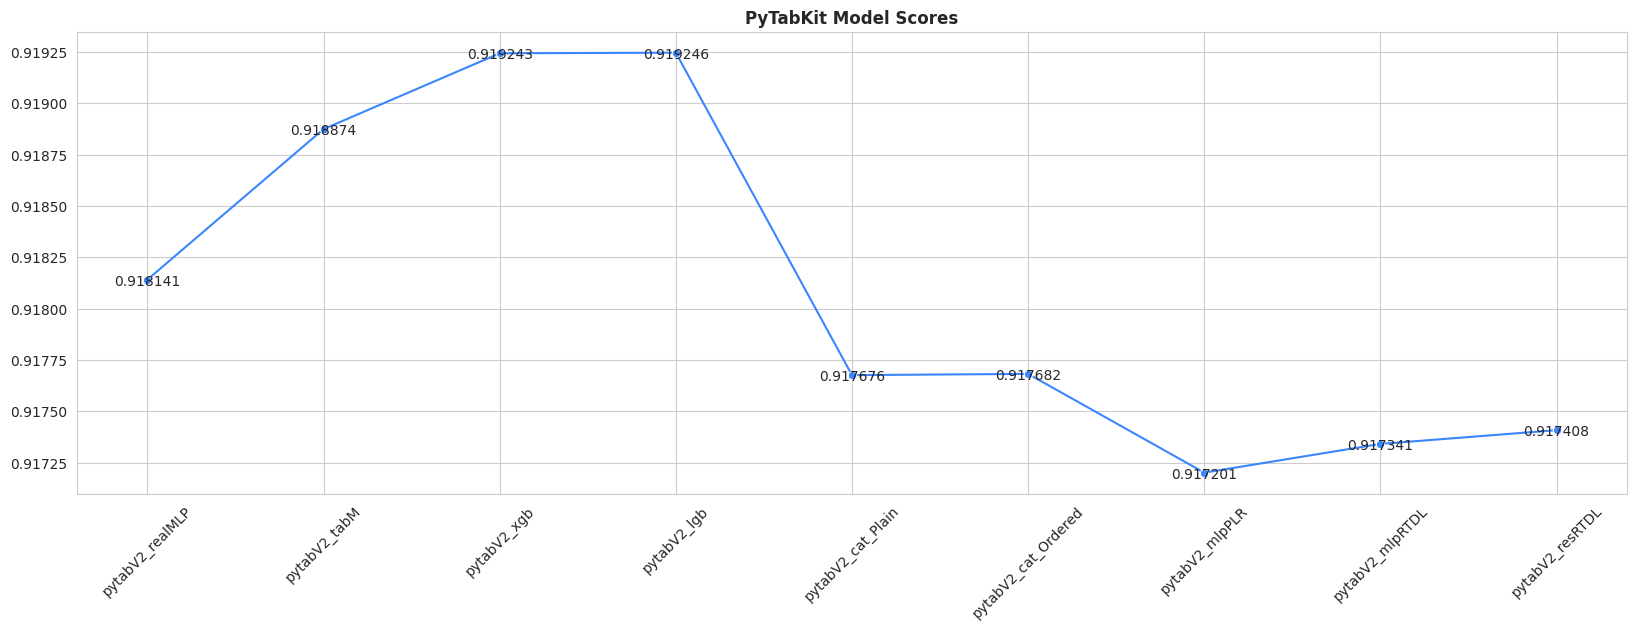

In [36]:
## -- Get models scores --
all_model_scores = {}

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

plt.figure(figsize=(20, 6))
sns.lineplot(all_model_scores, marker='o')
# pd.Series(all_model_scores).plot(marker='o')
for i, score in enumerate(all_model_scores.values()):
    plt.text(float(i), score+1e-6, score, ha='center', va='center_baseline')

plt.title('PyTabKit Model Scores', fontweight='semibold')
plt.tick_params('x', rotation=45)
plt.show()

In [37]:
## -- Get oof predictions --
all_model_oof = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_oof = pd.concat([all_model_oof, pd.DataFrame({n: y})], axis=1)

all_model_oof.to_parquet(f"oof_{version_name}.parquet", index=False)
all_model_oof.head()

,pytabV2_realMLP_918141,pytabV2_tabM_918874,pytabV2_xgb_919243,pytabV2_lgb_919246,pytabV2_cat_Plain_917676,pytabV2_cat_Ordered_917682,pytabV2_mlpPLR_917201,pytabV2_mlpRTDL_917341,pytabV2_resRTDL_917408
0,0.059008,0.020714,0.013572,0.011722,0.011290,0.011178,0.013975,0.011050,0.014620
1,0.052778,0.001803,0.000947,0.001111,0.002485,0.002184,0.000191,0.000217,0.000783
2,0.340794,0.278447,0.324121,0.313264,0.362496,0.370186,0.271281,0.274439,0.341830
3,0.809476,0.748460,0.716736,0.713435,0.817562,0.798886,0.778710,0.796341,0.807491
4,0.811432,0.803741,0.799869,0.781850,0.836759,0.840772,0.812246,0.684044,0.811548


In [38]:
## -- Get test predictions --
all_model_test = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_test = pd.concat([all_model_test, pd.DataFrame({n: y})], axis=1)

all_model_test.to_parquet(f"test_{version_name}.parquet", index=False)
all_model_test.head()

,pytabV2_realMLP_918141,pytabV2_tabM_918874,pytabV2_xgb_919243,pytabV2_lgb_919246,pytabV2_cat_Plain_917676,pytabV2_cat_Ordered_917682,pytabV2_mlpPLR_917201,pytabV2_mlpRTDL_917341,pytabV2_resRTDL_917408
0,0.135750,0.141421,0.144598,0.139082,0.109208,0.114306,0.098049,0.133324,0.147499
1,0.049756,0.002110,0.000830,0.001002,0.002971,0.002321,0.001135,0.000689,0.001039
2,0.148218,0.132811,0.112370,0.108909,0.108572,0.108418,0.108054,0.127435,0.121570
3,0.051842,0.007512,0.005408,0.004639,0.004804,0.003936,0.003328,0.002656,0.004716
4,0.479319,0.486011,0.551416,0.539115,0.510088,0.510489,0.489759,0.521348,0.485045


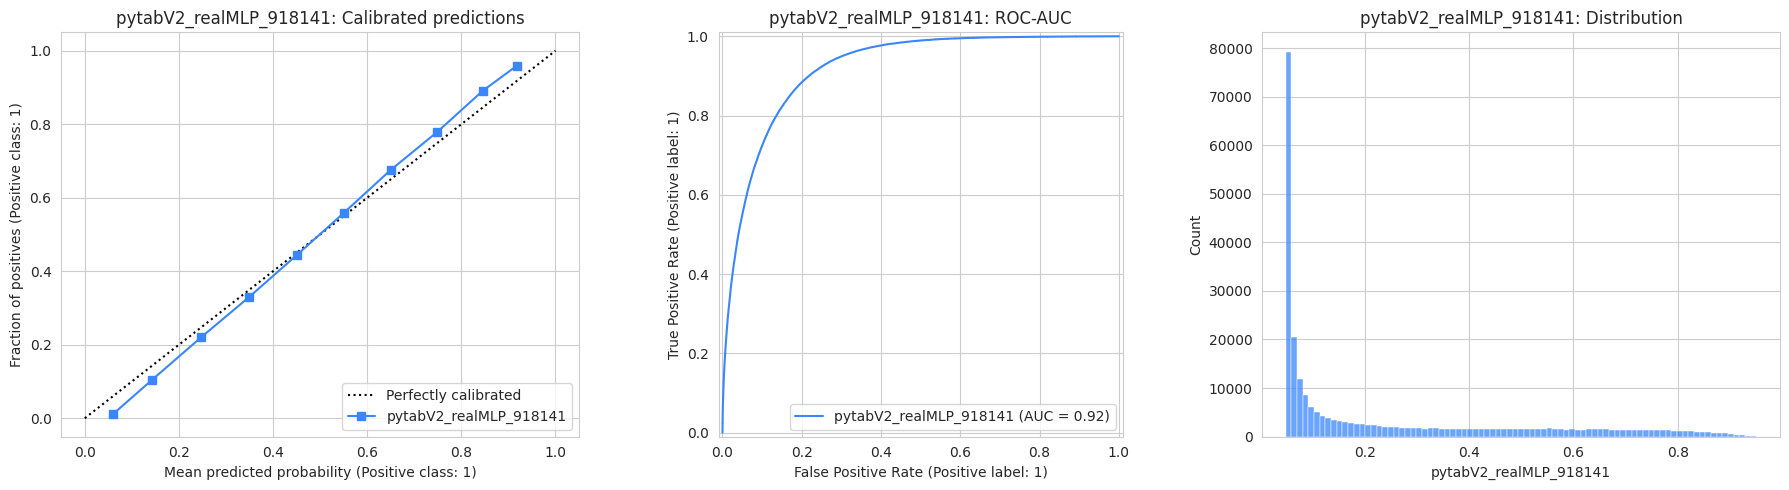

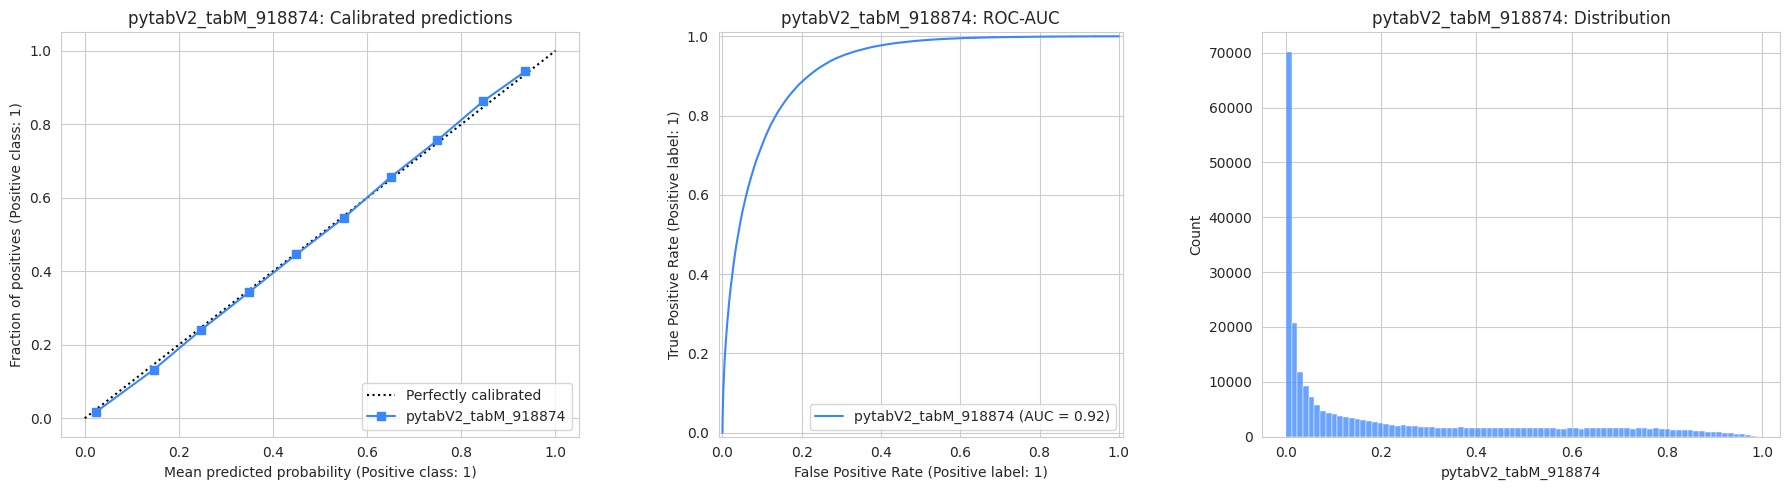

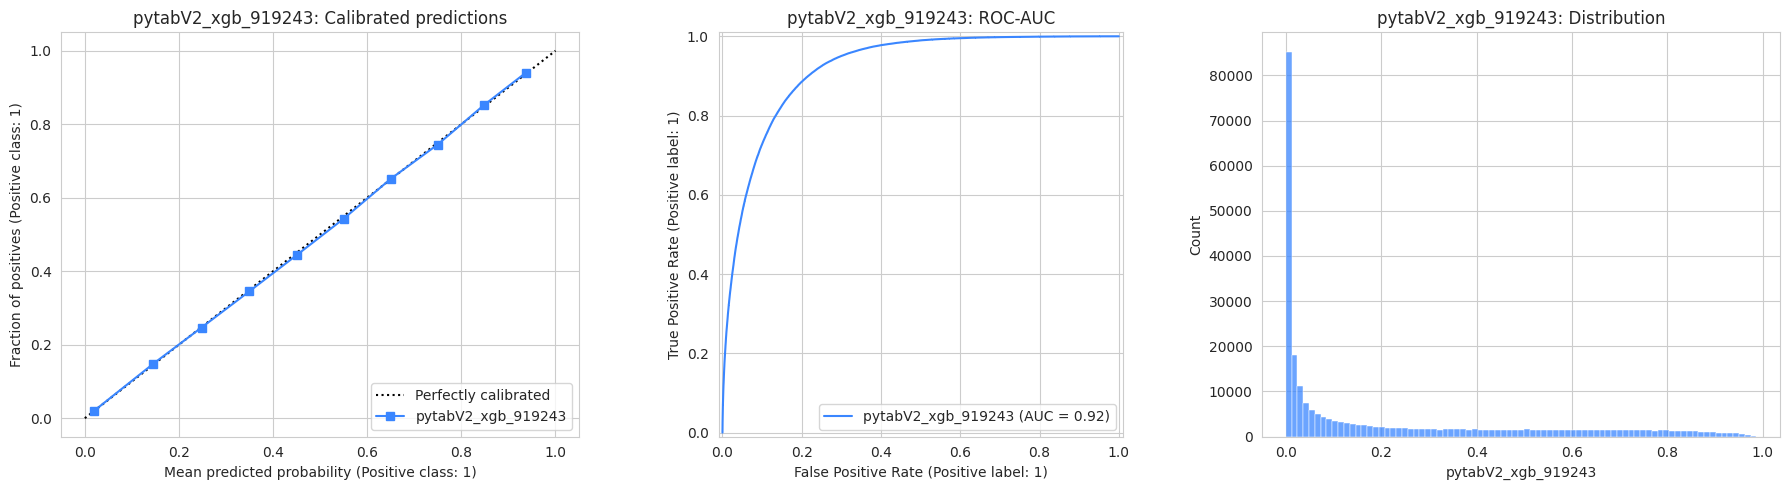

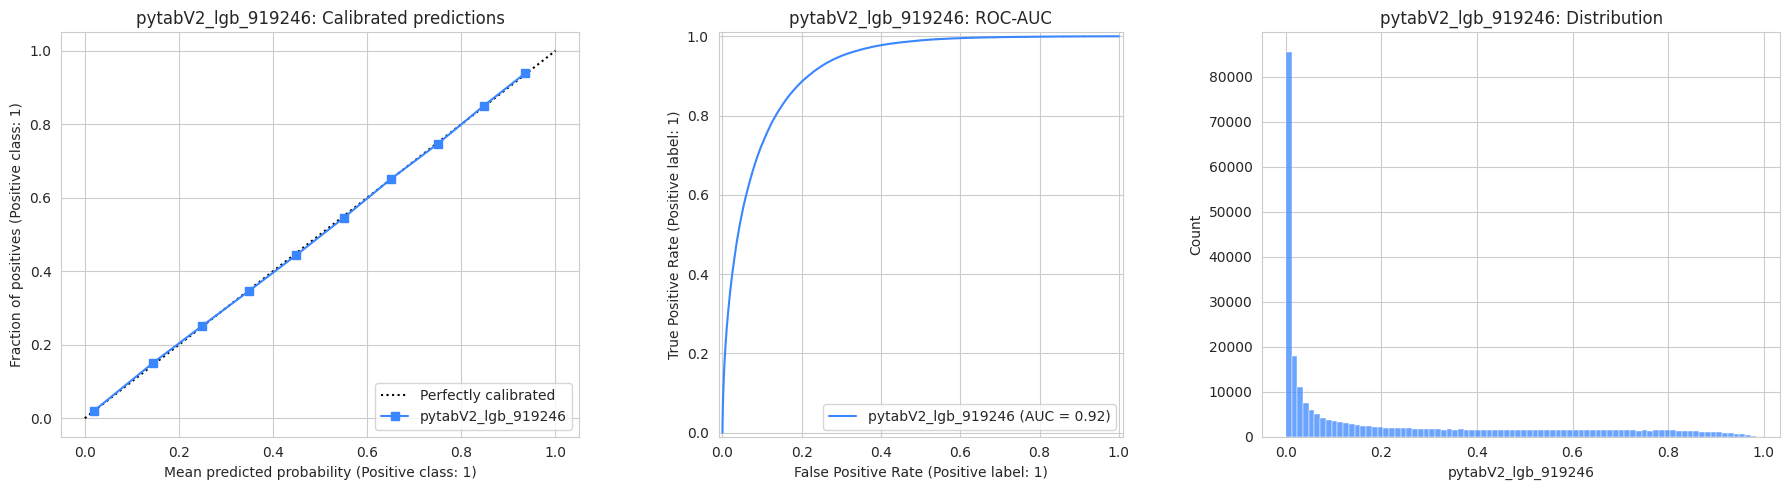

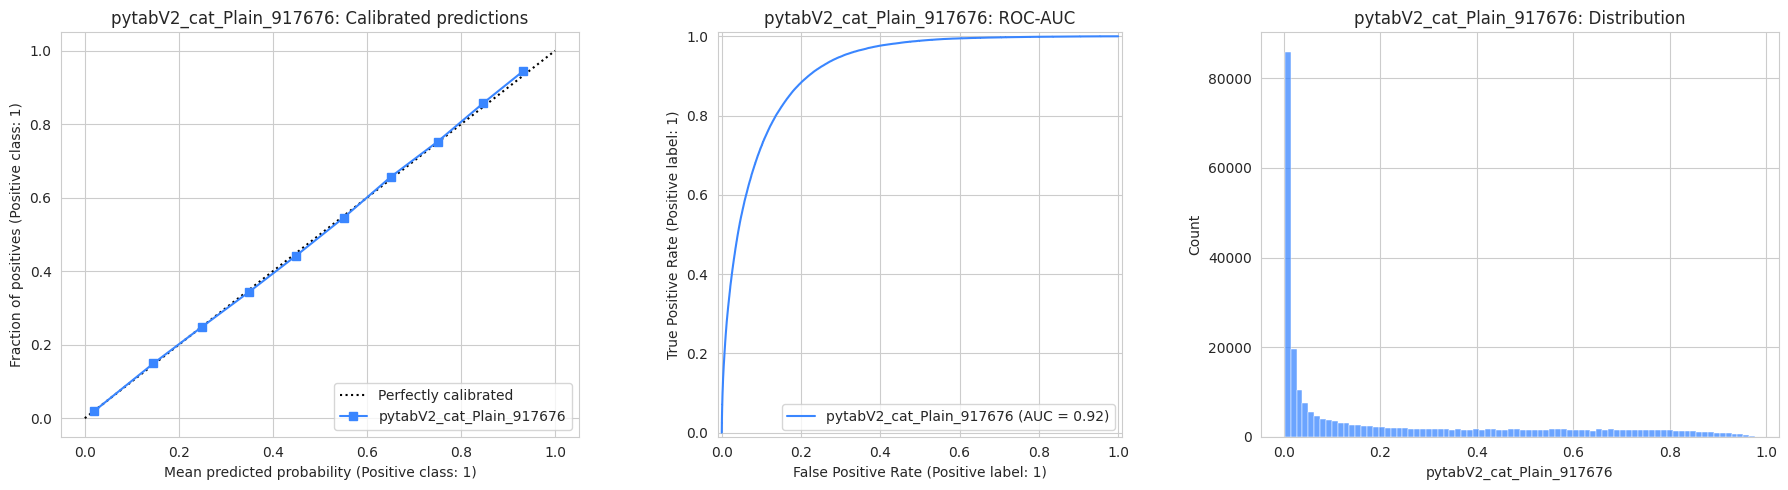

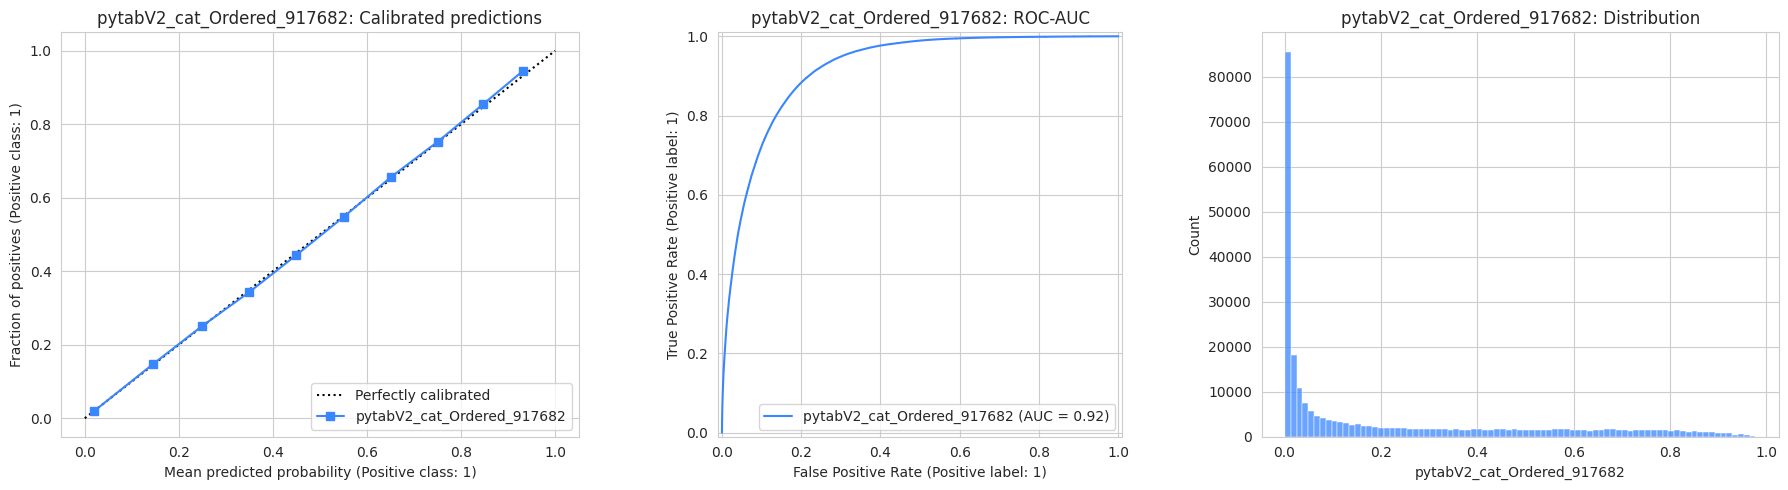

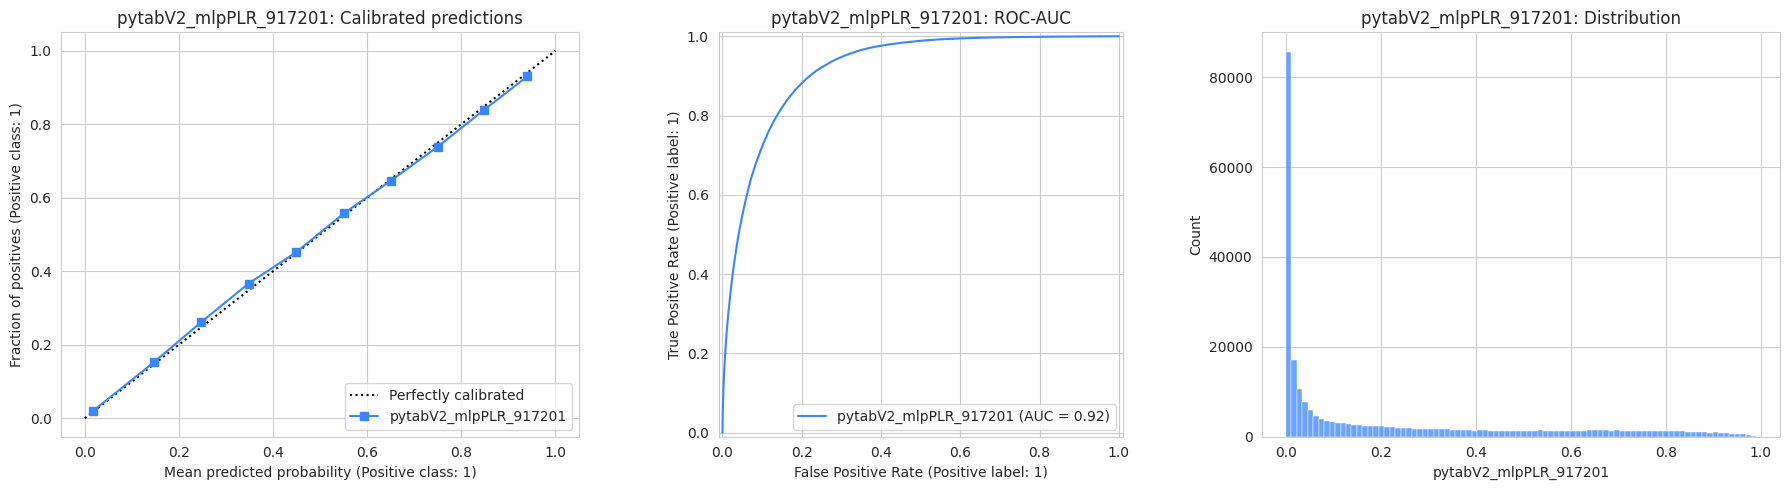

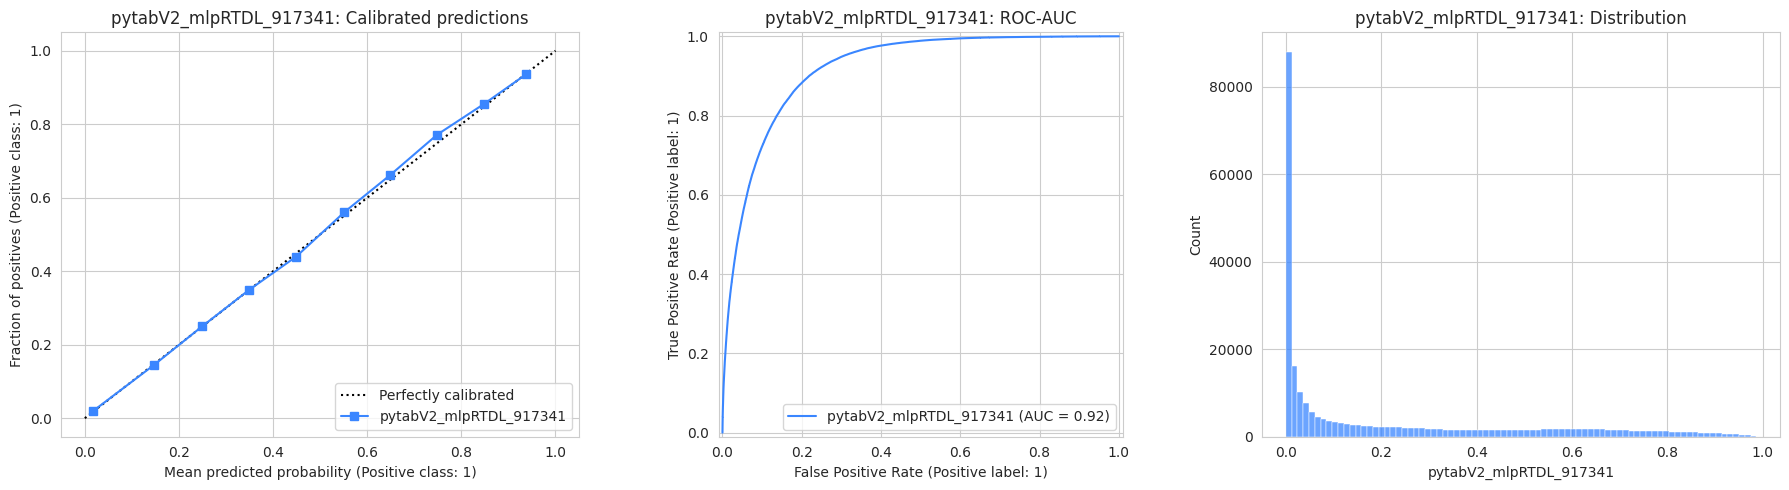

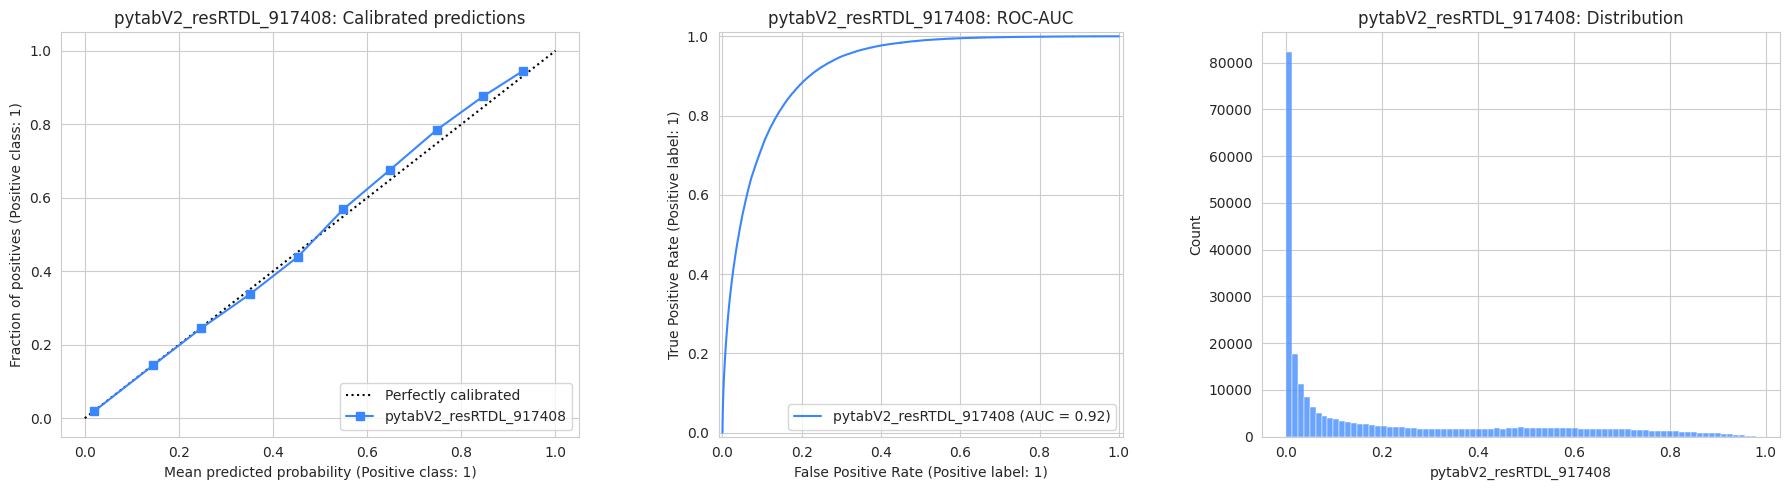

In [39]:
## -- PLOT PREDICTIONS --
for i, n in enumerate(all_model_test.columns):
    _, axs = plt.subplots(1, 3, figsize=(18, 5))

    CalibrationDisplay.from_predictions(train[TARGET], all_model_oof[n], n_bins=10, name=n, ax=axs[0])
    axs[0].set_title(f"{n}: Calibrated predictions")

    RocCurveDisplay.from_predictions(train[TARGET], all_model_oof[n], name=n, ax=axs[1])
    axs[1].set_title(f"{n}: ROC-AUC")
    # axs[1].grid(False)

    sns.histplot(all_model_test[n], ax=axs[2])
    axs[2].set_title(f"{n}: Distribution")

    plt.tight_layout()
    plt.show()
    print()